In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
Data = pd.read_csv('/home/omnix/Desktop/Google_Playstore/Google-Playstore-EDA/Data/playstore.csv')

In [3]:
Data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [4]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [5]:
Data.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

<Axes: xlabel='Rating', ylabel='Count'>

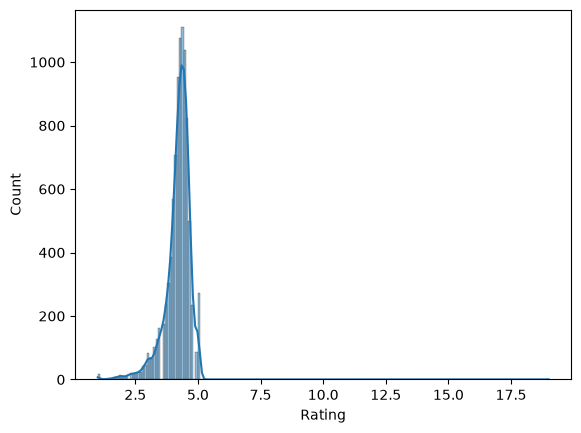

In [6]:
Data['Rating'].dtype
Numeric_Data=pd.to_numeric(Data['Rating'],errors='coerce')
Data['Rating']=Data['Rating'].fillna(Numeric_Data.median())
Data['Rating'].isnull().sum()
sns.histplot(Numeric_Data,kde=True)

In [7]:
Data['Reviews'].unique().value_counts()
Data.drop(Data[Data['Reviews']=='3.0M'].index,inplace=True)
Data['Reviews']=Data['Reviews'].astype(int)

In [8]:
Data['Size'].unique()
Data['Size']=Data['Size'].str.replace("M","000")
Data['Size']=Data['Size'].str.replace("k","")
Data['Size']=Data['Size'].replace("Varies with device",np.nan)
Data['Size']=Data['Size'].astype(float)

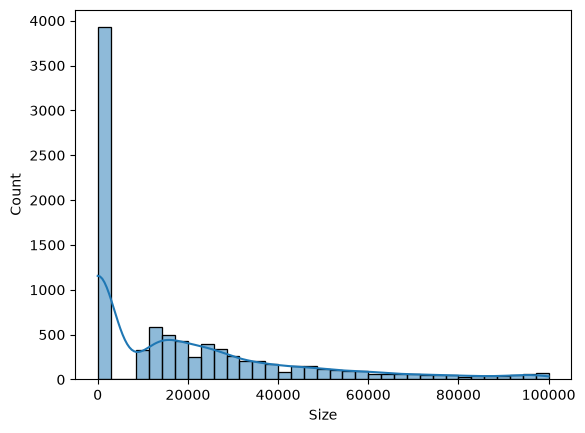

In [9]:

Numerical_Data = pd.to_numeric(Data['Size'],errors='coerce')
sns.histplot(Numerical_Data,kde=True)
Data['Size']=Data['Size'].fillna(Numerical_Data.median())

In [10]:
Data['Installs']=Data['Installs'].str.split("+",regex=False).str[0]

In [11]:
Data['Installs'] = Data['Installs'].str.replace(',', '', regex=False)
Data['Installs'] = pd.to_numeric(Data['Installs'], errors='coerce').astype('Int64')

In [12]:
Data.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          10840 non-null  float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  float64
 5   Installs        10840 non-null  Int64  
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: Int64(1), float64(2), int64(1), str(9)
memory usage: 1.2 MB


In [13]:
Data['Subscription_Type']=Data['Type'].map({'Free':0,"Paid":1,np.nan:0})
Data.drop('Type',axis=1,inplace=True)

# Data['Subscription_Type']=Data['Subscription_Type'].astype(int)

# Free : 0 
# Paid : 1


In [14]:
Data

,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Subscription_Type
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000.0,5000,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,0
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,0
10838,Parkinson Exercices FR,MEDICAL,4.3,3,9.5,1000,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,0
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,13000.0,1000,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,0


In [15]:
Data['Price'].unique()


<StringArray>
[      '0',   '$4.99',   '$3.99',   '$6.99',   '$1.49',   '$2.99',   '$7.99',
   '$5.99',   '$3.49',   '$1.99',   '$9.99',   '$7.49',   '$0.99',   '$9.00',
   '$5.49',  '$10.00',  '$24.99',  '$11.99',  '$79.99',  '$16.99',  '$14.99',
   '$1.00',  '$29.99',  '$12.99',   '$2.49',  '$10.99',   '$1.50',  '$19.99',
  '$15.99',  '$33.99',  '$74.99',  '$39.99',   '$3.95',   '$4.49',   '$1.70',
   '$8.99',   '$2.00',   '$3.88',  '$25.99', '$399.99',  '$17.99', '$400.00',
   '$3.02',   '$1.76',   '$4.84',   '$4.77',   '$1.61',   '$2.50',   '$1.59',
   '$6.49',   '$1.29',   '$5.00',  '$13.99', '$299.99', '$379.99',  '$37.99',
  '$18.99', '$389.99',  '$19.90',   '$8.49',   '$1.75',  '$14.00',   '$4.85',
  '$46.99', '$109.99', '$154.99',   '$3.08',   '$2.59',   '$4.80',   '$1.96',
  '$19.40',   '$3.90',   '$4.59',  '$15.46',   '$3.04',   '$4.29',   '$2.60',
   '$3.28',   '$4.60',  '$28.99',   '$2.95',   '$2.90',   '$1.97', '$200.00',
  '$89.99',   '$2.56',  '$30.99',   '$3.61', '$394

In [16]:
# Remove $ and convert to float
Data['Price'] = Data['Price'].str.replace('$', '', regex=False)
Data['Price'] = pd.to_numeric(Data['Price'], errors='coerce')

In [17]:
# Convert to datetime
Data['Last Updated'] = pd.to_datetime(Data['Last Updated'])

# Extract Year, Month, Day
Data['Year'] = Data['Last Updated'].dt.year
Data['Month'] = Data['Last Updated'].dt.month
Data['Day'] = Data['Last Updated'].dt.day

# Also can extract month name if needed
Data['Month_Name'] = Data['Last Updated'].dt.month_name()

# Check results
print(Data[['Last Updated', 'Year', 'Month', 'Day', 'Month_Name']].head())

  Last Updated  Year  Month  Day Month_Name
0   2018-01-07  2018      1    7    January
1   2018-01-15  2018      1   15    January
2   2018-08-01  2018      8    1     August
3   2018-06-08  2018      6    8       June
4   2018-06-20  2018      6   20       June


In [18]:
Data.drop(['Last Updated','Month_Name'],axis=1,inplace=True)

In [19]:
Data.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   App                10840 non-null  str    
 1   Category           10840 non-null  str    
 2   Rating             10840 non-null  float64
 3   Reviews            10840 non-null  int64  
 4   Size               10840 non-null  float64
 5   Installs           10840 non-null  Int64  
 6   Price              10840 non-null  float64
 7   Content Rating     10840 non-null  str    
 8   Genres             10840 non-null  str    
 9   Current Ver        10832 non-null  str    
 10  Android Ver        10838 non-null  str    
 11  Subscription_Type  10840 non-null  int64  
 12  Year               10840 non-null  int32  
 13  Month              10840 non-null  int32  
 14  Day                10840 non-null  int32  
dtypes: Int64(1), float64(3), int32(3), int64(2), str(6)
memory usage: 1.2 MB


In [20]:
Data.drop('Current Ver',axis=1,inplace=True)

In [21]:
Data.drop('Category',axis=1,inplace=True)

In [22]:
Data['Content Rating'].value_counts()

Content Rating
Everyone           8714
Teen               1208
Mature 17+          499
Everyone 10+        414
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

In [23]:
Data.drop(Data[Data['Content Rating']=='Unrated'].index,inplace=True)

In [24]:
Data['Application_Type']=Data['Genres']
Data.drop('Genres',axis=1,inplace=True)

In [25]:
Data.info()

<class 'pandas.DataFrame'>
Index: 10838 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   App                10838 non-null  str    
 1   Rating             10838 non-null  float64
 2   Reviews            10838 non-null  int64  
 3   Size               10838 non-null  float64
 4   Installs           10838 non-null  Int64  
 5   Price              10838 non-null  float64
 6   Content Rating     10838 non-null  str    
 7   Android Ver        10836 non-null  str    
 8   Subscription_Type  10838 non-null  int64  
 9   Year               10838 non-null  int32  
 10  Month              10838 non-null  int32  
 11  Day                10838 non-null  int32  
 12  Application_Type   10838 non-null  str    
dtypes: Int64(1), float64(3), int32(3), int64(2), str(4)
memory usage: 1.0 MB


In [26]:
Data['Android_version']=Data['Android Ver'].fillna(Data['Android Ver'].mode()[0])

In [27]:
Data.isnull().sum()

App                  0
Rating               0
Reviews              0
Size                 0
Installs             0
Price                0
Content Rating       0
Android Ver          2
Subscription_Type    0
Year                 0
Month                0
Day                  0
Application_Type     0
Android_version      0
dtype: int64

In [28]:
Data.drop(Data[Data['Android_version']=='Varies with device'].index,inplace=True)

In [29]:
Data

,App,Rating,Reviews,Size,Installs,Price,Content Rating,Android Ver,Subscription_Type,Year,Month,Day,Application_Type,Android_version
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,159,19000.0,10000,0.0,Everyone,4.0.3 and up,0,2018,1,7,Art & Design,4.0.3 and up
1,Coloring book moana,3.9,967,14000.0,500000,0.0,Everyone,4.0.3 and up,0,2018,1,15,Art & Design;Pretend Play,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,87510,8.7,5000000,0.0,Everyone,4.0.3 and up,0,2018,8,1,Art & Design,4.0.3 and up
3,Sketch - Draw & Paint,4.5,215644,25000.0,50000000,0.0,Teen,4.2 and up,0,2018,6,8,Art & Design,4.2 and up
4,Pixel Draw - Number Art Coloring Book,4.3,967,2.8,100000,0.0,Everyone,4.4 and up,0,2018,6,20,Art & Design;Creativity,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,4.0,7,2.6,500,0.0,Everyone,4.1 and up,0,2017,6,18,Education,4.1 and up
10835,FR Forms,4.3,0,9.6,10,0.0,Everyone,4.0 and up,0,2016,9,29,Business,4.0 and up
10836,Sya9a Maroc - FR,4.5,38,53000.0,5000,0.0,Everyone,4.1 and up,0,2017,7,25,Education,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,5.0,4,3.6,100,0.0,Everyone,4.1 and up,0,2018,7,6,Education,4.1 and up


In [30]:
Data['Size']

0        19000.0
1        14000.0
2            8.7
3        25000.0
4            2.8
          ...   
10834        2.6
10835        9.6
10836    53000.0
10837        3.6
10838        9.5
Name: Size, Length: 9476, dtype: float64

In [31]:
# Check unique values
print("Application Type Distribution:")
print(Data['Application_Type'].value_counts().head(20))

# Split multiple categories and take the first one
Data['Primary_Application_Type'] = Data['Application_Type'].str.split(';').str[0]


# Check result
print("\nPrimary Application Type Distribution:")
print(Data['Primary_Application_Type'].value_counts().head(10))

Application Type Distribution:
Application_Type
Tools                743
Entertainment        552
Education            499
Medical              439
Business             419
Personalization      354
Lifestyle            351
Action               349
Sports               346
Productivity         319
Finance              313
Communication        286
Photography          278
Health & Fitness     268
Dating               222
Social               220
News & Magazines     220
Arcade               207
Shopping             205
Books & Reference    200
Name: count, dtype: int64

Primary Application Type Distribution:
Primary_Application_Type
Tools              743
Entertainment      591
Education          582
Medical            439
Business           419
Action             365
Personalization    354
Lifestyle          353
Sports             350
Productivity       319
Name: count, dtype: int64


In [32]:
# Check Size column
print("Size statistics:")
print(Data['Size'].describe())

# Check for outliers
print(f"\nTop 10 largest sizes:")
print(Data.nlargest(10, 'Size')[['App', 'Size']])

Size statistics:
count      9476.000000
mean      19309.384044
std       23601.535288
min           1.000000
25%           5.875000
50%       13000.000000
75%       29000.000000
max      100000.000000
Name: Size, dtype: float64

Top 10 largest sizes:
                                    App      Size
1080                          Post Bank  100000.0
1565     Talking Babsy Baby: Baby Games  100000.0
1758             Hungry Shark Evolution  100000.0
1793  Mini Golf King - Multiplayer Game  100000.0
1988             Hungry Shark Evolution  100000.0
2299               Navi Radiography Pro  100000.0
3973             Hungry Shark Evolution  100000.0
4690                         Vi Trainer  100000.0
5427                    Ultimate Tennis  100000.0
5530        The Walking Dead: Our World  100000.0


In [33]:
# Reviews should be integer
Data['Reviews'] = Data['Reviews'].astype('Int64')

In [34]:
Data.drop(Data[Data['Installs']<=0].index,inplace=True)

In [35]:
Data.drop(columns=['Android Ver'], inplace=True)

In [36]:
Data.to_csv('/home/omnix/Desktop/Google_Playstore/Google-Playstore-EDA/Data/Cleaned_Data.csv',index=False)